**MAESTRÍA EN INTELIGENCIA ARTIFICIAL APLICADA**

**Curso: TC5053 - Ciencia y analítica de datos**

Tecnológico de Monterrey

Prof Grettel Barceló Alonso

**Semana 7**
Análisis de Componentes Principales (PCA)

---

EQUIPO 28   
INTEGRANTES :
*   TERESA DE JESUS MORENO MARTINEZ -A01840597
*   FRIDA ALEJANDRA MOYAO LEÓN - A01026354
*   ANA CRISTINA MUNGUÍA ROMERO - A01740019
*   MARCO ANTONIO MUÑOZ CHAVEZ - A01686968

En esta actividad trabajarás con el archivo `automobile_dataset.csv`, basado en un conjunto de datos sobre características técnicas y especificaciones de automóviles, disponible en el repositorio UCI Machine Learning.

Los datos fueron recopilados para analizar diferentes aspectos de los vehículos y sus precios, e incluyen información sobre el fabricante, tipo de motor, dimensiones, peso, rendimiento de combustible y otras especificaciones técnicas. Los indicadores incluidos son:

* `symboling`: Nivel de riesgo del seguro del automóvil, de -3 (bajo riesgo) a +3 (alto riesgo)
* `normalized_losses`: Pérdidas normalizadas del seguro (valor numérico de la aseguradora, algunas veces faltante)
* `make`: Marca del automóvil (por ejemplo, Audi, BMW, Honda)
* `fuel_type`: Tipo de combustible (gasolina o diésel)
* `aspiration`: Tipo de aspiración del motor (normal o turbo)
* `num_doors`: Número de puertas del automóvil (dos o cuatro)
* `body_style`: Estilo de carrocería (sedán, hatchback, wagon, hardtop, convertible)
* `drive_wheels`: Tipo de tracción (fwd: delantera, rwd: trasera, 4wd: en las cuatro ruedas)
* `engine_location`: Ubicación del motor (delantero o trasero)
* `wheel_base`: Distancia entre ejes (en pulgadas)
* `length`: Largo total del automóvil (en pulgadas)
* `width`: Ancho total del automóvil (en pulgadas)
* `height`: Altura total del automóvil (en pulgadas)
* `curb_weight`: Peso del automóvil sin carga (en libras)
* `engine_type`: Tipo de motor (OHV, OHC, DOHC, etc.)
* `num_cylinders`: Número de cilindros del motor
* `engine_size`: Tamaño del motor (en cc)
* `fuel_system`: Sistema de combustible (por ejemplo, mpfi, 2bbl, 4bbl)
* `bore`: Diámetro del cilindro (en pulgadas)
* `stroke`: Carrera del pistón (en pulgadas)
* `compression_ratio`: Relación de compresión del motor
* `horsepower`: Potencia del motor (en caballos de fuerza)
* `peak_rpm`: Revoluciones máximas por minuto
* `city_mpg`: Rendimiento de combustible en ciudad (millas por galón)
* `highway_mpg`: Rendimiento de combustible en carretera (millas por galón)
* `price`: Precio del automóvil (en dólares estadounidenses) Es la variable de salida o *target*, es decir, la que se pretende predecir más adelante al construir el modelo.

**NOTA IMPORTANTE:** Asegúrate de responder *explícitamente* todos los cuestionamientos.

In [1]:
# Importar las bibliotecas necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

1. Descarga el archivo: `automobile_dataset.csv` y guarda, en un dataframe (`cars_df`), todos sus registros.
* Utiliza el método `info()` del dataframe, para obtener el resumen de los tipos de datos. ¿Cuántas columnas son numéricas y cuántas de texto?
* Al revisar los primeros registros, notarás que la columna `normalized_losses` contiene el símbolo `?`. Esto sugiere que se utilizó para indicar valores faltantes. Identifica todas las columnas que presentan este símbolo.
* Sustituye el símbolo `?` por valores faltantes (`NaN`) y convierte las columnas al tipo de dato adecuado. Esto es necesario porque la presencia del símbolo pudo haber hecho que pandas las interpretara como object, aunque en realidad no lo fueran.

In [2]:
# Leer el csv para crear el df
cars_df = pd.read_csv ('automobile_dataset.csv')
# Obtener resumen de tipos de datos
cars_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   normalized_losses  205 non-null    object 
 2   make               205 non-null    object 
 3   fuel_type          205 non-null    object 
 4   aspiration         205 non-null    object 
 5   num_doors          205 non-null    object 
 6   body_style         205 non-null    object 
 7   drive_wheels       205 non-null    object 
 8   engine_location    205 non-null    object 
 9   wheel_base         205 non-null    float64
 10  length             205 non-null    float64
 11  width              205 non-null    float64
 12  height             205 non-null    float64
 13  curb_weight        205 non-null    int64  
 14  engine_type        205 non-null    object 
 15  num_cylinders      205 non-null    int64  
 16  engine_size        205 non

In [3]:
# Determinar cantidad de columnas numéricas y de texto
print(f"Hay {len(cars_df.select_dtypes(include=[np.number]).columns)} columnas numéricas")
print(f"Hay {len(cars_df.select_dtypes(include=['object', 'string']).columns)} columnas de texto")

Hay 11 columnas numéricas
Hay 15 columnas de texto


In [4]:
# La columna 'normalized_losses' contiene el símbolo '?'
cars_df[["normalized_losses"]].head()

,normalized_losses
0,?
1,?
2,?
3,164
4,164


In [5]:
# Podemos inferir que '?' se usó para marcar la presencia de valores faltantes
# Hay que encontrar todas las columnas que presentan este símbolo ('?')
cars_df.eq('?').any()

,0
symboling,False
normalized_losses,True
make,False
fuel_type,False
aspiration,False
num_doors,False
body_style,False
drive_wheels,False
engine_location,False
wheel_base,False


In [6]:
columns_with_nan = [col for col in cars_df.columns[cars_df.eq('?').any()].values]
print(f"Las columnas que presentan el símbolo '?' son: {columns_with_nan}")

Las columnas que presentan el símbolo '?' son: ['normalized_losses', 'bore', 'stroke', 'horsepower', 'peak_rpm', 'price']


In [7]:
# Sustituir símbolo '?' por valores faltantes (NaN)
cars_df = cars_df.replace('?', np.nan)

cars_df[columns_with_nan] = cars_df[columns_with_nan].apply(pd.to_numeric)
print()
print("---------------------------------------------------------")
print("--------------- Tipos de datos corregidos ---------------")
print("---------------------------------------------------------")
print(cars_df[columns_with_nan].info())


---------------------------------------------------------
--------------- Tipos de datos corregidos ---------------
---------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   normalized_losses  164 non-null    float64
 1   bore               201 non-null    float64
 2   stroke             201 non-null    float64
 3   horsepower         203 non-null    float64
 4   peak_rpm           203 non-null    float64
 5   price              201 non-null    float64
dtypes: float64(6)
memory usage: 9.7 KB
None


# Análisis exploratorio de datos (univariado)

2. Antes de iniciar con el análisis univariado, verifica si hay valores duplicados e imprime el porcentaje de faltantes por columna.
* Obtén las estadísticas descriptivas, separado las numéricas (incluye asimetría y curtosis) y las categóricas (incluye tablas de frecuencias).
* Genera histogramas para las numéricas y diagramas de barras para las categóricas.

In [8]:
# Buscar valores duplicados
print(f"Número de registros duplicados: {cars_df.duplicated().sum()}")
cars_df[cars_df.duplicated()]

Número de registros duplicados: 0


,symboling,normalized_losses,make,fuel_type,aspiration,num_doors,body_style,drive_wheels,engine_location,wheel_base,...,engine_size,fuel_system,bore,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg,price


In [9]:
# Imprimir porcentaje de valores faltantes por columna
missing_percentage = cars_df.isnull().sum() * 100 / len(cars_df)
missing_percentage

,0
symboling,0.00000
normalized_losses,20.00000
make,0.00000
fuel_type,0.00000
aspiration,0.00000
num_doors,0.00000
body_style,0.00000
drive_wheels,0.00000
engine_location,0.00000
wheel_base,0.00000


In [10]:
# Obtener estadísticas descriptivas para las variables numéricas
cars_df.select_dtypes(include=[np.number]).describe()

,symboling,normalized_losses,wheel_base,length,width,height,curb_weight,num_cylinders,engine_size,bore,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg,price
count,205.000000,164.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,201.000000,201.000000,205.000000,203.000000,203.000000,205.000000,205.000000,201.000000
mean,0.834146,122.000000,98.756585,174.049268,65.907805,53.724878,2555.565854,4.380488,126.907317,3.329751,3.255423,10.142537,104.256158,5125.369458,25.219512,30.751220,13207.129353
std,1.245307,35.442168,6.021776,12.337289,2.145204,2.443522,520.680204,1.080854,41.642693,0.273539,0.316717,3.972040,39.714369,479.334560,6.542142,6.886443,7947.066342
min,-2.000000,65.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,2.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,0.000000,94.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,4.000000,97.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7775.000000
50%,1.000000,115.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,4.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,2.000000,150.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,4.000000,141.000000,3.590000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16500.000000
max,3.000000,256.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,12.000000,326.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


In [11]:
# Obtener sesgo y curtosis para las variables numéricas
cars_df.select_dtypes(include=[np.number]).agg(['skew', 'kurtosis'])

,symboling,normalized_losses,wheel_base,length,width,height,curb_weight,num_cylinders,engine_size,bore,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg,price
skew,0.211072,0.765976,1.050214,0.155954,0.904003,0.063123,0.681398,2.817459,1.947655,0.020016,-0.683122,2.610862,1.391029,0.073237,0.663704,0.539997,1.809675
kurtosis,-0.676271,0.525440,1.017039,-0.082895,0.702764,-0.443812,-0.042854,13.714866,5.305682,-0.828945,2.074243,5.233054,2.623280,0.056526,0.578648,0.440070,3.231537


In [12]:
# Definir variables categóricas con el dtype categorical
categorical_cols = cars_df.select_dtypes(include="object").columns
cars_df[categorical_cols] = cars_df[categorical_cols].astype("category")

# Obtener estadísticas descriptivas para las variables categóricas
cars_df.select_dtypes(include="category").describe()

,make,fuel_type,aspiration,num_doors,body_style,drive_wheels,engine_location,engine_type,fuel_system
count,205,205,205,205,205,205,205,205,205
unique,22,2,2,2,5,3,2,7,8
top,toyota,gas,std,four,sedan,fwd,front,ohc,mpfi
freq,32,185,168,116,96,120,202,148,94


In [13]:
# Obtener tablas de frecuencia para las variables categóricas
cars_df[categorical_cols].value_counts()

make        fuel_type  aspiration  num_doors  body_style  drive_wheels  engine_location  engine_type  fuel_system
honda       gas        std         two        hatchback   fwd           front            ohc          1bbl           7
bmw         gas        std         four       sedan       rwd           front            ohc          mpfi           5
mitsubishi  gas        turbo       two        hatchback   fwd           front            ohc          spdi           5
mazda       gas        std         two        hatchback   fwd           front            ohc          2bbl           5
                                   four       sedan       fwd           front            ohc          2bbl           4
                                                                                                                    ..
volkswagen  gas        std         two        hatchback   fwd           front            ohc          mpfi           1
volvo       diesel     turbo       four       sedan       rwd           front            ohc          idi            1
volkswagen  gas        std         two        sedan       fwd           front            ohc          mpfi           1
volvo       gas        std         four       sedan       rwd           front            ohcv         mpfi           1
                       turbo       four       wagon       rwd           front            ohc          mpfi           1
Name: count, Length: 126, dtype: int64

# Análisis exploratorio de datos (bivariado)

3. Genera algunos gráficos bivariados para familiarizarte con el conjunto de datos:
* Gráfico de barras apiladas normalizadas que muestra la distribución de los tipos de tracción para cada fabricante.
* Diagrama de cajas para visualizar cómo se distribuye el precio de los automóviles según el estilo de carrocería. Esto permitirá comparar la mediana, los cuartiles y la presencia de valores atípicos entre los diferentes tipos de carrocería.
* Gráfico de barras que muestre los 10 automóviles más caros, ordenados de mayor a menor precio, con cada barra diferenciada por fabricante.
* Diagrama de dispersión para explorar la relación entre el tamaño del motor y el precio de los automóviles. Diferencia con colores los puntos según el tipo de aspiración y con el tamaño de los puntos el número de puertas.

**Nota.** Debes incluir en cada gráfico una conclusión de lo observado.

<Figure size 640x480 with 0 Axes>

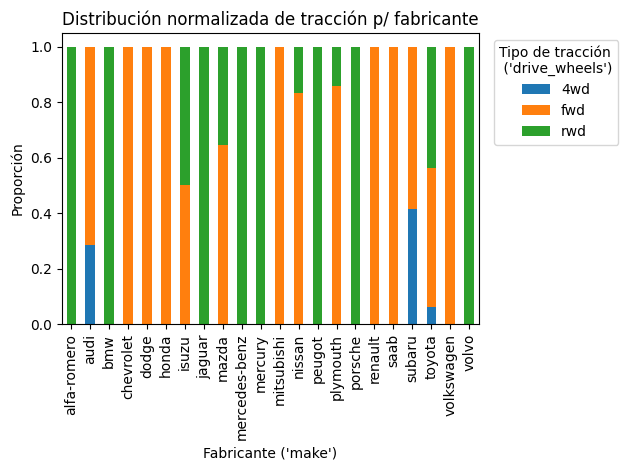

Conclusión: En está gráfica podemos observar que predomina el tipo de tracción delantera en la mayoría de los fabricantes,
solo hay ocho fabricantes que presentan exclusivamente tracción trasera
7 fabricantes que fabrican modelos con tracción trasera y delantera
y solo hay 3 fabricantes que fabrican modelos con tracción en las 4 ruedas


In [14]:
# Generar gráficos bivariados

## Gráfico de barras apiladas normalizadas -- Tipos de tracción (drive_wheels) p/ fabricante (make)
ct = pd.crosstab(cars_df["make"], cars_df["drive_wheels"], normalize="index")  # filas suman 1

plt.figure()
ct.plot(kind="bar", stacked=True)
plt.title("Distribución normalizada de tracción p/ fabricante")
plt.xlabel("Fabricante ('make')")
plt.ylabel("Proporción")
plt.legend(title="Tipo de tracción\n ('drive_wheels')", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

print(f"Conclusión: En está gráfica podemos observar que predomina el tipo de tracción delantera en la mayoría de los fabricantes,")
print(f"solo hay ocho fabricantes que presentan exclusivamente tracción trasera")
print(f"7 fabricantes que fabrican modelos con tracción trasera y delantera")
print(f"y solo hay 3 fabricantes que fabrican modelos con tracción en las 4 ruedas")


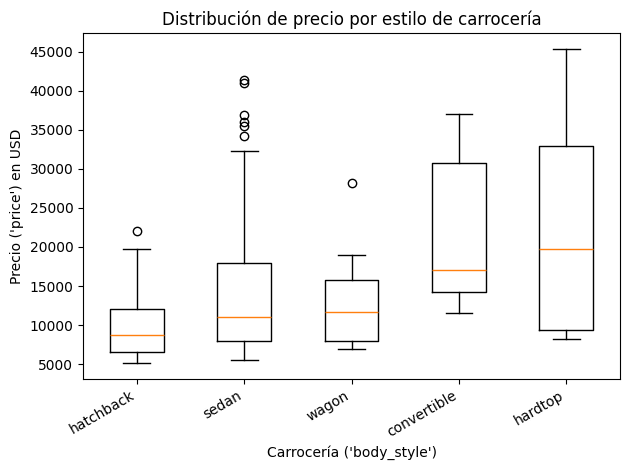

Conclusión: En está gráfica podemos observar que los estilos de carrocería más costosos son:
'Hardtop' y 'convertible', por el contrario, los modelos más económicos son:
'Hatchback' y 'Wagon'


In [15]:
## Diagrama de cajas -- Distribución del precio (price) según estilo de carrocería (body_style)

# No incluir valores faltantes (NaN) en el gráfico
tmp = cars_df.dropna(subset=["price"]).copy()

# Ordenar categorías por mediana de precio
order = tmp.groupby("body_style", observed=False)["price"].median().sort_values().index.tolist()

data = [tmp.loc[tmp["body_style"] == bs, "price"].values for bs in order]

plt.figure()
plt.boxplot(data, tick_labels=order, showfliers=True)
plt.title("Distribución de precio por estilo de carrocería")
plt.xlabel("Carrocería ('body_style')")
plt.ylabel("Precio ('price') en USD")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

print(f"Conclusión: En está gráfica podemos observar que los estilos de carrocería más costosos son:")
print(f"'Hardtop' y 'convertible', por el contrario, los modelos más económicos son:")
print(f"'Hatchback' y 'Wagon'")


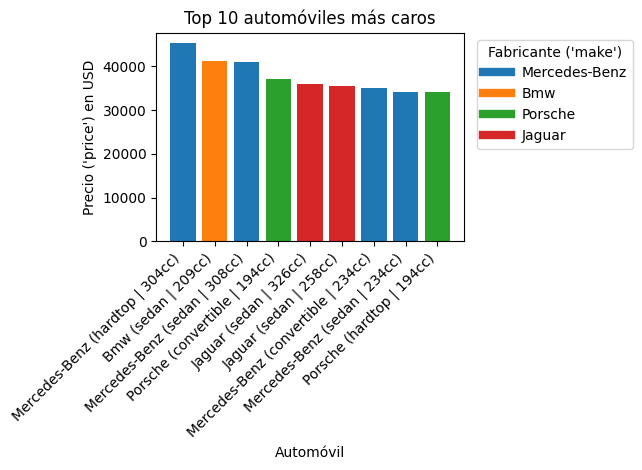

Conclusión: En está gráfica podemos observar que el auto más caro es el Mercedes-Benz Hardtop 304cc,
El Fabricante 'Mercedes-Benz'es el fabricante con más autos caros con un total de 4.
Los fabricantes 'Porsche' y'Jaguar' cuentan con dos autos en el top 10 respectivamente.
Y por último, 'BMW' solo cuenta con un modelo en el top 10.


In [17]:
## Gráfico de barras ordenadas (descendiente) -- Top 10 autos más caros diferenciados p/ fabricante (make)

# Solo incluir los 10 autos más caros en el gráfico (y no incluir NaNs)
top10 = cars_df.dropna(subset=["price"]).sort_values("price", ascending=False).head(10).copy()

# Crear un "label" de modelo (aprox.)
extra = []
for _, r in top10.iterrows():
    parts = [r.get("body_style"), str(int(r["engine_size"])) + "cc"]
    parts = [p for p in parts]
    extra.append(" | ".join(parts))
top10["car_label"] = [f"{m.title()} ({e})" for m, e in zip(top10["make"], extra)]

# Colores por fabricante
makes = top10["make"].unique().tolist()
color_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]
make_to_color = {m: color_cycle[i % len(color_cycle)] for i, m in enumerate(makes)}
bar_colors = top10["make"].map(make_to_color).tolist()

plt.figure()
plt.bar(top10["car_label"], top10["price"], color=bar_colors)
plt.title("Top 10 automóviles más caros")
plt.xlabel("Automóvil")
plt.ylabel("Precio ('price') en USD")
plt.xticks(rotation=45, ha="right")

# Leyenda de fabricantes
handles = [plt.Line2D([0], [0], color=make_to_color[m], lw=6) for m in makes]
labels = [m.title() for m in makes]
plt.legend(handles, labels, title="Fabricante ('make')", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

print(f"Conclusión: En está gráfica podemos observar que el auto más caro es el Mercedes-Benz Hardtop 304cc,")
print(f"El Fabricante 'Mercedes-Benz'es el fabricante con más autos caros con un total de 4.")
print(f"Los fabricantes 'Porsche' y'Jaguar' cuentan con dos autos en el top 10 respectivamente.")
print(f"Y por último, 'BMW' solo cuenta con un modelo en el top 10.")

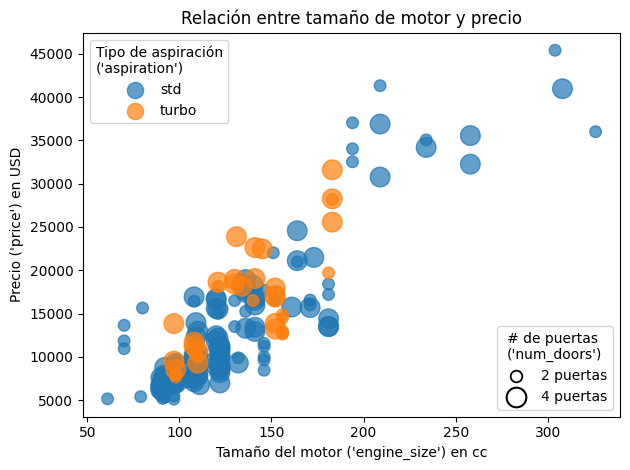

Conclusión: Los autos con motores mas grandes también se encuentra en el top de autos más caros.


In [19]:
## Diagrama de dispersión -- Relación entre el tamaño del motor (engine_size) y el precio del auto (price)
##                           diferenciado p/ tipo de aspiración (aspiration) + # de puertas (num_doors)

# No incluir valores faltantes (NaN) en el gráfico
tmp = cars_df.dropna(subset=["price"]).copy()

# Definir tamaño de punto p/ # de puertas (2 vs 4)
door_map = {"two": 70, "four": 200}
tmp["pt_size"] = tmp["num_doors"].astype("string").map(door_map).astype(int)

plt.figure()
# Graficar por tipo de aspiración
for asp, g in tmp.groupby("aspiration", observed=False):
    plt.scatter(g["engine_size"], g["price"], s=g["pt_size"], alpha=0.7, label=str(asp))

plt.title("Relación entre tamaño de motor y precio")
plt.xlabel("Tamaño del motor ('engine_size') en cc")
plt.ylabel("Precio ('price') en USD")

# Agregar leyenda de tipo de aspiración (color de punto)
asp_legend = plt.legend(title="Tipo de aspiración\n('aspiration')", loc="upper left")
plt.gca().add_artist(asp_legend)

# Agregar leyenda de número de puertas (tamaño de punto)
size_handles = [
    plt.scatter([], [], s=door_map["two"], alpha=1, color='white', edgecolors='black', linewidths=1.3),
    plt.scatter([], [], s=door_map["four"], alpha=1, color='white', edgecolors='black', linewidths=1.5),
]
size_labels = ["2 puertas", "4 puertas"]
plt.legend(size_handles, size_labels, title="# de puertas\n('num_doors')", loc="lower right")

plt.tight_layout()
plt.show()

print(f"Conclusión: Los autos con motores mas grandes también se encuentra en el top de autos más caros.")



4. Genera un mapa de calor de la matriz de correlación entre las variables numéricas del conjunto de datos, mostrando los valores de correlación en cada celda.
* ¿Cuáles son las tres variables más correlacionadas con el precio?

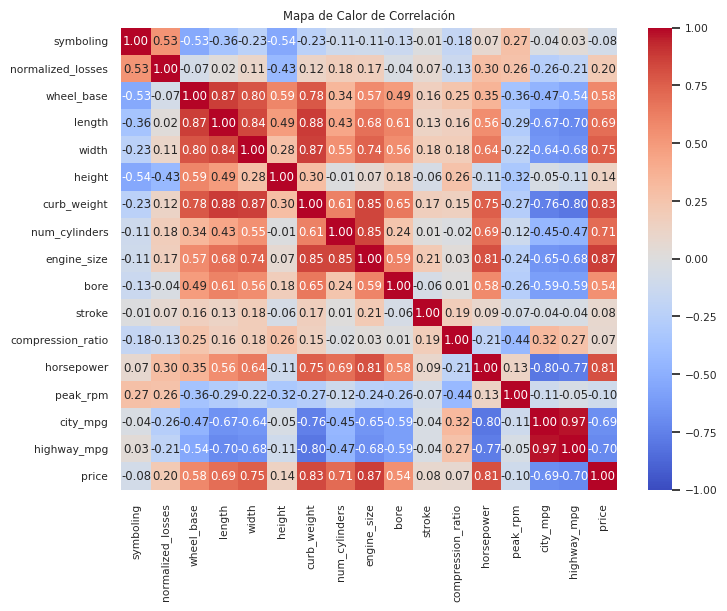

Las variables más correlacionadas con el precio son:
    - 'engine_size' --> 0.87
    - 'curb_weight' --> 0.83
    - 'horsepower'  --> 0.81


In [20]:
# Calcular matriz de correlación
corr_matrix = cars_df.corr(numeric_only=True)

sns.set(font_scale=.7)

# Generar mapa de calor
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title('Mapa de Calor de Correlación')
plt.show()

print(f"Las variables más correlacionadas con el precio son:")
print(f"    - 'engine_size' --> 0.87")
print(f"    - 'curb_weight' --> 0.83")
print(f"    - 'horsepower'  --> 0.81")

En el análisis de correlación se observa que existen muchos pares de variables altamente correlacionadas, lo que puede afectar el desempeño de los modelos de regresión. PCA resulta útil no solo para reducir la dimensionalidad, sino también porque los componentes principales son ortogonales entre sí, es decir, tienen correlación cero, evitando problemas de multicolinealidad. Esto lo podrás comprobrar más adelante.

# Ingeniería de características

5. Realiza las siguientes operaciones de ingeniería de características en las variables numéricas:
* Aplica `SimpleImputer` para tratar los valores faltantes, justificando la estrategia de imputación seleccionada.
* Considera `price` como la variable objetivo y guárdala en `y`. Separa los predictores numéricos en `X`. Con base en estos datos, ¿cuántos componentes principales se generarán al aplicar PCA?
* Escala los valores de `X` para que todas las variables contribuyan equitativamente y ninguna domine el análisis por tener una escala mayor.

PCA está diseñado principalmente para variables numéricas y funciona encontrando combinaciones lineales de las variables originales que capturan la mayor varianza en los datos. Normalmente se recomienda eliminar las variables categóricas antes de aplicar PCA y luego concatenarlas nuevamente con los resultados de PCA si se desea.



In [21]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Separar variables numéricas (sin price) y variable objetivo
numeric_cols = cars_df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols.remove('price')
X = cars_df[numeric_cols].copy()
y = cars_df['price'].copy()

# Imputar con mediana (robusta ante outliers)
imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=numeric_cols)

print(f"Número de predictores numéricos: {len(numeric_cols)}")
print("Se generarán", len(numeric_cols), "componentes principales")
print(f"Estrategia: Se aplicó SimpleImputer con estrategia de mediana para imputar los valores faltantes en las variables numéricas.")
print(f"La mediana fue elegida por su robustez ante valores atípicos y distribuciones asimétricas.")
print(f"Esto permite conservar mejor la distribución original de los datos")
# Escalar los datos
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_imputed), columns=numeric_cols)

print("\nMedias después del escalado (deben ser 0):")
print(X_scaled.mean().round(2))
print("\nDesviaciones después del escalado (deben ser 1):")
print(X_scaled.std().round(2))



Número de predictores numéricos: 16
Se generarán 16 componentes principales
Estrategia: Se aplicó SimpleImputer con estrategia de mediana para imputar los valores faltantes en las variables numéricas.
La mediana fue elegida por su robustez ante valores atípicos y distribuciones asimétricas.
Esto permite conservar mejor la distribución original de los datos

Medias después del escalado (deben ser 0):
symboling            0.0
normalized_losses    0.0
wheel_base          -0.0
length               0.0
width                0.0
height              -0.0
curb_weight          0.0
num_cylinders       -0.0
engine_size          0.0
bore                 0.0
stroke               0.0
compression_ratio   -0.0
horsepower          -0.0
peak_rpm             0.0
city_mpg             0.0
highway_mpg          0.0
dtype: float64

Desviaciones después del escalado (deben ser 1):
symboling            1.0
normalized_losses    1.0
wheel_base           1.0
length               1.0
width                1.0
height 

6. Aplica `PCA` a los datos escalados para proyectarlos en el nuevo espacio de vectores.
* Asigna nombres descriptivos a los componentes principales en el dataframe resultante, utilizando la convención PC1, PC2, PC3, y así sucesivamente.
* Genera un mapa de calor con la matriz de correlaciones de los componentes principales para verificar que sean independientes entre sí.



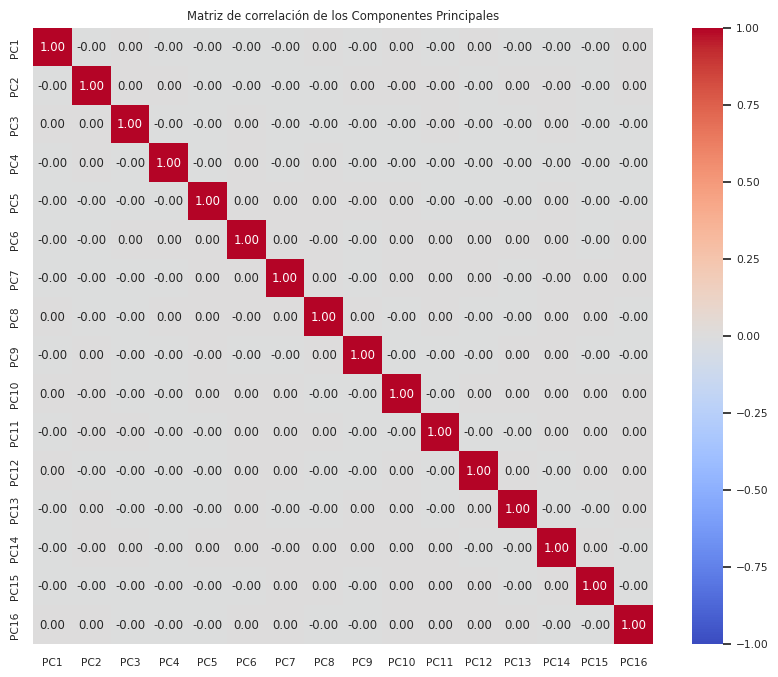

Correlación máxima fuera de diagonal: 2.58e-14
Los componentes son ortogonales (independientes).


In [22]:
# Aplicar PCA a los datos escalados

from sklearn.decomposition import PCA

# Aplicar PCA (se generan tantos componentes como variables)
pca = PCA()
X_pca = pca.fit_transform(X_scaled)  # X_scaled de la pregunta 5

# Crear DataFrame con nombres PC1, PC2, ...
pca_columns = [f'PC{i+1}' for i in range(X_pca.shape[1])]
X_pca_df = pd.DataFrame(X_pca, columns=pca_columns, index=X_scaled.index)

# Mapa de calor de correlaciones
corr_pca = X_pca_df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_pca, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')
plt.title('Matriz de correlación de los Componentes Principales')
plt.show()

# Verificar independencia (correlaciones ≈ 0)
max_corr = corr_pca.where(~np.eye(corr_pca.shape[0], dtype=bool)).abs().max().max()
print(f"Correlación máxima fuera de diagonal: {max_corr:.2e}")
print("Los componentes son ortogonales (independientes)." if max_corr < 1e-10
      else "Posible correlación entre componentes.")

7. Obtén el porcentaje de varianza explicada por cada componente.
* Grafica la curva de varianza acumulada para determinar el número mínimo de componentes principales que explican más del 90% de la varianza total.


PC1: 44.55% (acumulado: 44.55%)
PC2: 17.93% (acumulado: 62.48%)
PC3: 8.58% (acumulado: 71.05%)
PC4: 6.44% (acumulado: 77.49%)
PC5: 5.74% (acumulado: 83.23%)
PC6: 4.78% (acumulado: 88.01%)
PC7: 3.25% (acumulado: 91.26%)
PC8: 2.73% (acumulado: 93.98%)
PC9: 1.94% (acumulado: 95.92%)
PC10: 1.55% (acumulado: 97.48%)
PC11: 0.75% (acumulado: 98.23%)
PC12: 0.63% (acumulado: 98.86%)
PC13: 0.51% (acumulado: 99.37%)
PC14: 0.35% (acumulado: 99.73%)
PC15: 0.16% (acumulado: 99.88%)
PC16: 0.12% (acumulado: 100.00%)


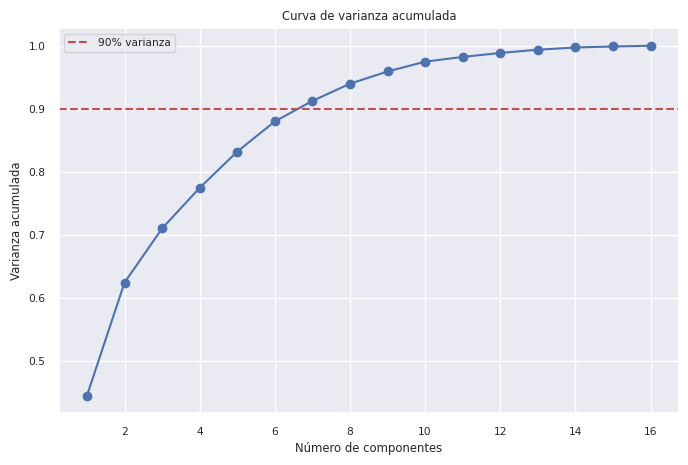


Número mínimo de componentes que explican más del 90% de la varianza: 7


In [23]:
# Varianza explicada por cada componente
explained_var = pca.explained_variance_ratio_
cumulative_var = explained_var.cumsum()

# Mostrar porcentajes
for i, (ev, cv) in enumerate(zip(explained_var, cumulative_var), 1):
    print(f'PC{i}: {ev:.2%} (acumulado: {cv:.2%})')

# Gráfico de varianza acumulada
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_var)+1), cumulative_var, 'bo-')
plt.axhline(y=0.9, color='r', linestyle='--', label='90% varianza')
plt.xlabel('Número de componentes')
plt.ylabel('Varianza acumulada')
plt.title('Curva de varianza acumulada')
plt.grid(True)
plt.legend()
plt.show()

# Número mínimo de componentes para >90%
n_components = (cumulative_var >= 0.9).argmax() + 1
print(f'\nNúmero mínimo de componentes que explican más del 90% de la varianza: {n_components}')

8. Imprime la información de los componentes seleccionados (cargas o pesos de las variables originales) para interpretar qué variables contribuyen más a cada componente principal.
* Dibuja un diagrama de barras que muestre qué variables originales aportan más al primer componente principal (PC1), para visualizar su influencia relativa.



                     PC1    PC2    PC3    PC4    PC5    PC6    PC7
symboling         -0.097 -0.403  0.265 -0.072 -0.366  0.173  0.128
normalized_losses  0.016 -0.331  0.308 -0.343 -0.376 -0.492 -0.323
wheel_base         0.298  0.265 -0.029 -0.228 -0.004 -0.183 -0.106
length             0.338  0.139 -0.044 -0.194 -0.074 -0.082 -0.009
width              0.334  0.055  0.109 -0.098 -0.016 -0.107  0.140
height             0.114  0.422 -0.282 -0.186 -0.017 -0.214 -0.003
curb_weight        0.362  0.022  0.080 -0.025 -0.042 -0.014  0.061
num_cylinders      0.245 -0.114  0.177  0.552  0.237 -0.354 -0.068
engine_size        0.330 -0.082  0.199  0.296  0.109  0.016 -0.073
bore               0.263  0.003 -0.138  0.041 -0.373  0.512  0.126
stroke             0.052  0.034  0.512 -0.431  0.572  0.364 -0.153
compression_ratio  0.016  0.361  0.490  0.001 -0.234 -0.090  0.614
horsepower         0.298 -0.276  0.010  0.165  0.109  0.066  0.224
peak_rpm          -0.087 -0.364 -0.257 -0.289  0.341 -0.282  0

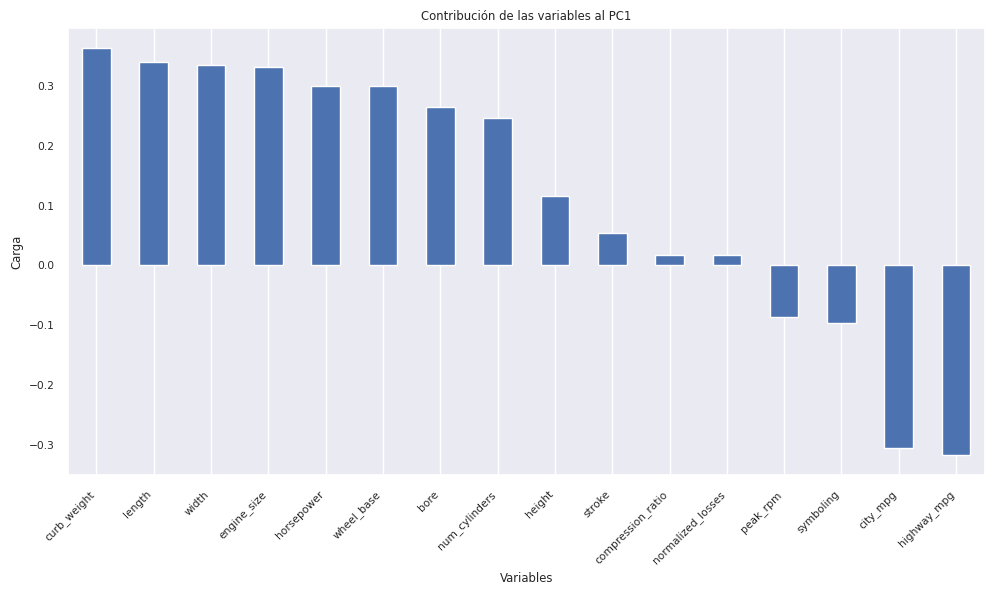

Se interpreta que las variables con mayor peso positivo corresponden a dimensiones físicas y prestaciones del vehículo,
por el contrario las cargas negativas más significativas son highway_mpg y city_mpg -0.306


In [24]:
# Obtención de cargas y gráficos
loadings = pca.components_.T
loadings_df = pd.DataFrame(loadings,
                           columns=[f'PC{i+1}' for i in range(loadings.shape[1])],
                           index=numeric_cols)
print(loadings_df.iloc[:, :7].round(3))

plt.figure(figsize=(10,6))
loadings_df['PC1'].sort_values(ascending=False).plot(kind='bar')
plt.title('Contribución de las variables al PC1')
plt.xlabel('Variables')
plt.ylabel('Carga')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

print(f"Se interpreta que las variables con mayor peso positivo corresponden a dimensiones físicas y prestaciones del vehículo,")
print(f"por el contrario las cargas negativas más significativas son highway_mpg y city_mpg -0.306")

9. Codifica las variables categóricas mediante *One-Hot Encoding* y utiliza el parámetro `drop='first'` para evitar problemas de multicolinealidad entre las variables dummy generadas.



In [25]:
# Identificar variables categóricas
cat_cols = cars_df.select_dtypes(include=['object', 'category']).columns.tolist()

# One-hot encoding con drop='first'
cars_encoded = pd.get_dummies(cars_df, columns=cat_cols, drop_first=True, dtype=int)

# Mostrar dimensiones y nuevas columnas
print(f"Dimensiones originales: {cars_df.shape}")
print(f"Dimensiones después de codificar: {cars_encoded.shape}")
print(cars_encoded.head())

Dimensiones originales: (205, 26)
Dimensiones después de codificar: (205, 61)
   symboling  normalized_losses  wheel_base  length  width  height  \
0          3                NaN        88.6   168.8   64.1    48.8   
1          3                NaN        88.6   168.8   64.1    48.8   
2          1                NaN        94.5   171.2   65.5    52.4   
3          2              164.0        99.8   176.6   66.2    54.3   
4          2              164.0        99.4   176.6   66.4    54.3   

   curb_weight  num_cylinders  engine_size  bore  ...  engine_type_ohcf  \
0         2548              4          130  3.47  ...                 0   
1         2548              4          130  3.47  ...                 0   
2         2823              6          152  2.68  ...                 0   
3         2337              4          109  3.19  ...                 0   
4         2824              5          136  3.19  ...                 0   

   engine_type_ohcv  engine_type_rotor  fuel_syste

10. Conjunta, en un dataframe, las valores proyectados en los componentes seleccionados (mínimo), las transformaciones obtenidas de las variables categóricas y la variable de salida.
* Almacena el dataframe resultante en archivo.

In [26]:
componentes = (cumulative_var >= 0.9).argmax() + 1
pca_columns_to_select = [f'PC{i+1}' for i in range(n_components)]
price_not_null_mask = cars_df['price'].notna()
X_pca_df.index = cars_df.index
pca_components_filtered = X_pca_df.loc[price_not_null_mask, pca_columns_to_select]
cols_to_drop_from_encoded = numeric_cols + ['price']
ohe_features_df = cars_encoded.drop(columns=cols_to_drop_from_encoded)
ohe_features_filtered = ohe_features_df.loc[price_not_null_mask]
y_filtered = y.loc[price_not_null_mask]
final_df = pd.concat([pca_components_filtered, ohe_features_filtered, y_filtered], axis=1)

print(f"Dataframe final: {final_df.shape}")
print(final_df.head())
print("\nInfo del dataframe final:")
final_df.info()

# Almacenar el DataFrame resultante en un archivo CSV
archivonuevo = 'final_dataset.csv'
final_df.to_csv(archivonuevo, index=False)
print(f"\nDataFrame combinado guardado en '{archivonuevo}'")

Dataframe final: (201, 52)
        PC1       PC2       PC3       PC4       PC5       PC6       PC7  \
0 -0.918474 -2.397150 -0.410501  1.416623 -1.822817  1.203190  0.369729   
1 -0.918474 -2.397150 -0.410501  1.416623 -1.822817  1.203190  0.369729   
2  0.634430 -1.372747  0.872496  0.998222  1.834717 -0.774751 -0.515065   
3 -0.361470 -0.919214  0.451578 -1.489124 -0.269938 -0.789900  0.000484   
4  1.172393 -1.794960  0.183773 -1.083812  0.113486 -0.861858 -0.353900   

   make_audi  make_bmw  make_chevrolet  ...  engine_type_ohcv  \
0          0         0               0  ...                 0   
1          0         0               0  ...                 0   
2          0         0               0  ...                 1   
3          1         0               0  ...                 0   
4          1         0               0  ...                 0   

   engine_type_rotor  fuel_system_2bbl  fuel_system_4bbl  fuel_system_idi  \
0                  0                 0                